# Cell Death Analysis — Debug Notebook

Standalone analysis from **linked labels** (skips segmentation & tracking).  
Imports the analysis functions directly from `cell_death_gui.py`.

## Inputs needed
- Original multi-channel TIFF
- `linked_labels_trackmate.tiff` (from tracking stage)
- `trackmate_tracks.csv` (optional, for trajectory/timeline plots)

In [1]:
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict
from skimage.filters import (
    gaussian,
    threshold_mean,
    threshold_minimum,
    threshold_otsu,
    threshold_triangle,
    threshold_yen,
)
from skimage.measure import label, regionprops
from matplotlib.collections import LineCollection
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

%matplotlib inline

In [2]:
# ═══════════════════════════════════════════════════════════════════════
# Analysis functions (COM-based assignment)
# ═══════════════════════════════════════════════════════════════════════

def _measure_cell_shape(binary_mask):
    """Return (area, roundness) for a single-cell binary mask."""
    area = int(np.count_nonzero(binary_mask))
    if area == 0:
        return 0, np.nan
    props = regionprops(binary_mask.astype(np.uint8))
    if not props:
        return area, np.nan
    p = props[0]
    major = p.major_axis_length
    minor = p.minor_axis_length
    roundness = minor / major if major > 0 else np.nan
    return area, roundness


def _assign_positive_objects_to_cells(positive_labels_frame, linked_labels_frame):
    """For each positive object, find its centroid and assign it to the cell
    whose label is at that centroid position.

    Returns dict: cell_label_id -> total positive area assigned to it.
    """
    cell_positive_area = {}
    props = regionprops(positive_labels_frame)
    for p in props:
        cy, cx = int(round(p.centroid[0])), int(round(p.centroid[1]))
        cy = max(0, min(cy, linked_labels_frame.shape[0] - 1))
        cx = max(0, min(cx, linked_labels_frame.shape[1] - 1))
        cell_id = int(linked_labels_frame[cy, cx])
        if cell_id > 0:
            cell_positive_area[cell_id] = cell_positive_area.get(cell_id, 0) + p.area
    return cell_positive_area


def segment_fluorescence(stacks, blur_sigma=1.0, threshold_method="mean"):
    """Blur, threshold, and label fluorescence stacks (1-3 fluorophores)."""
    threshold_functions = {
        "mean": threshold_mean,
        "minimum": threshold_minimum,
        "yen": threshold_yen,
        "otsu": threshold_otsu,
        "triangle": threshold_triangle,
    }
    if isinstance(threshold_method, str):
        _thresh_map = {name: threshold_method.lower() for name in stacks}
    else:
        _thresh_map = {name: str(threshold_method.get(name, "mean")).lower()
                       for name in stacks}

    result = {"threshold_methods": _thresh_map, "blur_sigma": blur_sigma}
    for name, stack in stacks.items():
        tm_name = _thresh_map[name]
        if tm_name not in threshold_functions:
            raise ValueError(f"Unsupported threshold for '{name}': {tm_name}")
        fn = threshold_functions[tm_name]
        blurred = np.stack(
            [gaussian(f, sigma=blur_sigma, preserve_range=True) for f in stack],
            axis=0,
        )
        thresh = fn(blurred)
        positive = blurred > thresh
        positive_labels = np.stack(
            [label(f) for f in positive], axis=0
        ).astype(np.uint32)
        result[name] = {
            "blurred": blurred,
            "thresh": thresh,
            "positive": positive,
            "positive_labels": positive_labels,
        }
    return result


def compute_cell_positivity(linked_labels, pos_label_imgs, fluorophore_names):
    """Compute COM-based cell positivity ONCE for all downstream use.

    Returns
    -------
    frame_cell_pos : dict[str, dict[int, dict[int, int]]]
        {fluorophore: {frame: {cell_id: positive_area}}}
    positive_cell_labels : dict[str, ndarray]
        Per-fluorophore label images where only positive cells are shown
        (same shape as linked_labels).
    """
    n_frames = linked_labels.shape[0]
    frame_cell_pos = {}
    positive_cell_labels = {}
    for fn in fluorophore_names:
        frame_cell_pos[fn] = {}
        out = np.zeros_like(linked_labels)
        for frame in range(n_frames):
            cell_pos = _assign_positive_objects_to_cells(
                pos_label_imgs[fn][frame], linked_labels[frame]
            )
            frame_cell_pos[fn][frame] = cell_pos
            for cell_id in cell_pos:
                out[frame][linked_labels[frame] == cell_id] = cell_id
        positive_cell_labels[fn] = out
    return frame_cell_pos, positive_cell_labels


def assign_persistent_fates(linked_labels, frame_cell_pos):
    """Persistent mode: fate = whichever fluorophore appears FIRST.

    Parameters
    ----------
    linked_labels : ndarray (n_frames, H, W)
    frame_cell_pos : dict  {fluorophore: {frame: {cell_id: area}}}
        Precomputed COM-based assignments from compute_cell_positivity.
    """
    n_frames = linked_labels.shape[0]
    label_ids = np.unique(linked_labels)
    label_ids = label_ids[label_ids > 0]
    fluor_names = list(frame_cell_pos.keys())

    rows = []
    frame_rows = []
    for label_id in label_ids:
        first_frames = {fn: None for fn in fluor_names}
        area_counts = {fn: 0 for fn in fluor_names}
        cell_areas = []
        cell_roundnesses = []
        for frame in range(n_frames):
            cell = linked_labels[frame] == label_id
            if not np.any(cell):
                continue
            area, roundness = _measure_cell_shape(cell)
            cell_areas.append(area)
            cell_roundnesses.append(roundness)
            fr = {"label_id": int(label_id), "frame": frame,
                  "area": area, "roundness": roundness}
            for fn in fluor_names:
                pos_count = frame_cell_pos[fn][frame].get(int(label_id), 0)
                area_counts[fn] += pos_count
                fr[f"{fn}_positive_area"] = pos_count
                if first_frames[fn] is None and pos_count > 0:
                    first_frames[fn] = frame
            frame_rows.append(fr)

        fate, first_positive = "negative", np.nan
        best = n_frames + 1
        for fn in fluor_names:
            ff = first_frames[fn]
            if ff is not None and ff < best:
                best, fate, first_positive = ff, fn, ff

        row = {"label_id": int(label_id)}
        row["mean_area"] = float(np.mean(cell_areas)) if cell_areas else np.nan
        row["mean_roundness"] = float(np.nanmean(cell_roundnesses)) if cell_roundnesses else np.nan
        for fn in fluor_names:
            row[f"first_{fn}_frame"] = (
                first_frames[fn] if first_frames[fn] is not None else np.nan
            )
            row[f"{fn}_positive_area"] = area_counts[fn]
        row["first_positive_frame"] = first_positive
        row["fate"] = fate
        rows.append(row)

    df = (
        pd.DataFrame(rows)
        .sort_values(["fate", "first_positive_frame", "label_id"])
        .reset_index(drop=True)
    )

    locked = {}
    for fn in fluor_names:
        ids = df.loc[df["fate"] == fn, "label_id"].to_numpy(dtype=np.uint32)
        locked[fn] = np.where(
            np.isin(linked_labels, ids), linked_labels, 0
        ).astype(np.uint32)

    per_frame_df = pd.DataFrame(frame_rows)
    if len(per_frame_df) > 0:
        fate_map = df.set_index("label_id")["fate"]
        per_frame_df["fate"] = per_frame_df["label_id"].map(fate_map)
        per_frame_df = per_frame_df.sort_values(
            ["label_id", "frame"]
        ).reset_index(drop=True)

    return df, locked, per_frame_df


def assign_snapshot_fates(linked_labels, frame_cell_pos):
    """Snapshot mode: per-frame classification by active fluorophores.

    Parameters
    ----------
    linked_labels : ndarray (n_frames, H, W)
    frame_cell_pos : dict  {fluorophore: {frame: {cell_id: area}}}
        Precomputed COM-based assignments from compute_cell_positivity.
    """
    fluor_names = list(frame_cell_pos.keys())
    rows = []
    for frame in range(linked_labels.shape[0]):
        fl = linked_labels[frame]
        for lid in np.unique(fl):
            if lid == 0:
                continue
            cell = fl == lid
            area, roundness = _measure_cell_shape(cell)
            lid_int = int(lid)
            active = {
                fn: frame_cell_pos[fn][frame].get(lid_int, 0) > 0
                for fn in fluor_names
            }
            cat = "+".join(fn for fn in fluor_names if active[fn]) or "negative"
            row = {"label_id": lid_int, "frame": frame,
                   "area": area, "roundness": roundness}
            row.update(active)
            for fn in fluor_names:
                row[f"{fn}_positive_area"] = frame_cell_pos[fn][frame].get(lid_int, 0)
            row["category"] = cat
            rows.append(row)

    return pd.DataFrame(rows)


# ═══════════════════════════════════════════════════════════════════════
# Percentages, filtering, and plotting
# ═══════════════════════════════════════════════════════════════════════

def compute_persistent_percentages(assignments_df, n_frames, fluor_names):
    n = len(assignments_df)
    if n == 0:
        raise ValueError("No tracked cells.")
    data = {"frame": np.arange(n_frames)}
    for fn in fluor_names:
        pcts = []
        for f in range(n_frames):
            c = (
                (assignments_df["fate"] == fn)
                & (assignments_df["first_positive_frame"] <= f)
            ).sum()
            pcts.append(100.0 * c / n)
        data[f"{fn}_pct"] = pcts
    data["total_positive_pct"] = [
        sum(data[f"{fn}_pct"][f] for fn in fluor_names) for f in range(n_frames)
    ]
    return pd.DataFrame(data)


def compute_snapshot_percentages(snapshot_df, n_frames):
    cats = sorted(
        snapshot_df["category"].unique(),
        key=lambda c: (c == "negative", c),
    )
    data = {"frame": np.arange(n_frames)}
    for cat in cats:
        pcts = []
        for f in range(n_frames):
            fd = snapshot_df[snapshot_df["frame"] == f]
            nt = len(fd)
            pcts.append(
                100.0 * (fd["category"] == cat).sum() / nt if nt > 0 else 0.0
            )
        data[f"{cat}_pct"] = pcts
    return pd.DataFrame(data), cats


# --- Colour inference ---

_COLOUR_KEYWORDS: Dict[str, dict] = {
    "red":     {"mpl": "tab:red",    "rgb": (1.0, 0.0, 0.0)},
    "green":   {"mpl": "tab:green",  "rgb": (0.0, 0.8, 0.0)},
    "blue":    {"mpl": "tab:blue",   "rgb": (0.2, 0.4, 1.0)},
    "yellow":  {"mpl": "goldenrod",  "rgb": (0.9, 0.85, 0.0)},
    "cyan":    {"mpl": "tab:cyan",   "rgb": (0.0, 0.8, 0.8)},
    "magenta": {"mpl": "tab:pink",   "rgb": (0.9, 0.0, 0.6)},
}

_FALLBACK_COLOURS = [
    {"mpl": "tab:red",    "rgb": (1.0, 0.0, 0.0)},
    {"mpl": "tab:green",  "rgb": (0.0, 0.8, 0.0)},
    {"mpl": "tab:blue",   "rgb": (0.2, 0.4, 1.0)},
    {"mpl": "tab:orange", "rgb": (1.0, 0.5, 0.0)},
    {"mpl": "tab:purple", "rgb": (0.5, 0.0, 0.8)},
]


def _infer_colour(name: str, index: int = 0) -> dict:
    low = name.lower()
    for kw, entry in _COLOUR_KEYWORDS.items():
        if kw in low:
            return entry
    return _FALLBACK_COLOURS[index % len(_FALLBACK_COLOURS)]


def _build_category_colormap(categories):
    singles = []
    for cat in categories:
        if cat == "negative":
            continue
        for part in cat.split("+"):
            if part not in singles:
                singles.append(part)
    single_rgb = {
        name: np.array(_infer_colour(name, i)["rgb"])
        for i, name in enumerate(singles)
    }
    cmap = {}
    for cat in categories:
        if cat == "negative":
            cmap[cat] = (0.7, 0.7, 0.7)
            continue
        parts = cat.split("+")
        rgb = np.zeros(3)
        for p in parts:
            rgb += single_rgb.get(p, np.array([0.5, 0.5, 0.5]))
        rgb = np.clip(rgb, 0, 1)
        cmap[cat] = tuple(rgb.tolist())
    return cmap


# --- Plotting ---

def plot_persistent_percentages(
    summary_df, fluor_names, title="Persistent positive cells over time"
):
    fig, ax = plt.subplots(figsize=(8, 4))
    for i, fn in enumerate(fluor_names):
        c = _infer_colour(fn, i)["mpl"]
        sns.lineplot(
            data=summary_df, x="frame", y=f"{fn}_pct",
            color=c, label=fn, ax=ax,
        )
    sns.lineplot(
        data=summary_df, x="frame", y="total_positive_pct",
        color="black", label="Total", ax=ax,
    )
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set(xlabel="Frame", ylabel="% Cells", ylim=(0, 100), title=title)
    plt.tight_layout()
    return fig, ax


def plot_snapshot_percentages(
    summary_df, categories, title="Per-frame categories over time"
):
    fig, ax = plt.subplots(figsize=(8, 4))
    cat_cmap = _build_category_colormap(categories)
    for cat in categories:
        c = cat_cmap.get(cat, (0.5, 0.5, 0.5))
        sns.lineplot(
            data=summary_df, x="frame", y=f"{cat}_pct",
            color=c, label=cat, ax=ax,
        )
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set(xlabel="Frame", ylabel="% Cells", ylim=(0, 100), title=title)
    plt.tight_layout()
    return fig, ax


# --- Filtering ---

def _filter_by_frame_presence(tracks_df, snapshot_df, n_frames, min_pct):
    threshold = n_frames * min_pct / 100.0
    frame_counts = snapshot_df.groupby("label_id")["frame"].nunique()
    keep_ids = frame_counts[frame_counts >= threshold].index
    filt_snap = snapshot_df[snapshot_df["label_id"].isin(keep_ids)].copy()
    if tracks_df is not None and len(tracks_df) > 0:
        keep_track_ids = keep_ids.astype(int) - 1
        filt_tracks = tracks_df[tracks_df["track_id"].isin(keep_track_ids)].copy()
    else:
        filt_tracks = tracks_df
    return filt_tracks, filt_snap


def _filter_persistent_by_frame_presence(
    assignments_df, linked_labels, n_frames, min_pct
):
    threshold = n_frames * min_pct / 100.0
    all_ids = []
    for frame in range(linked_labels.shape[0]):
        ids = np.unique(linked_labels[frame])
        ids = ids[ids > 0]
        all_ids.extend(ids.tolist())
    frame_counts = pd.Series(all_ids).value_counts()
    keep_ids = frame_counts[frame_counts >= threshold].index
    return assignments_df[assignments_df["label_id"].isin(keep_ids)].copy()


# --- Trajectory & timeline plots ---

def plot_snapshot_trajectories(
    tracks_df, snapshot_df, title="Snapshot trajectories by category",
):
    if tracks_df is None or len(tracks_df) == 0:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.set_title(title)
        ax.text(0.5, 0.5, "No tracks available", ha="center", va="center")
        ax.axis("off")
        plt.tight_layout()
        return fig, ax

    categories = sorted(snapshot_df["category"].unique())
    color_map = _build_category_colormap(categories)
    if "negative" not in color_map:
        color_map["negative"] = (0.6, 0.6, 0.6)

    pts = tracks_df.copy()
    pts["frame"] = pts["t"].astype(int)
    pts["label_id"] = pts["track_id"].astype(int) + 1

    cat_map = snapshot_df[["label_id", "frame", "category"]].copy()
    merged = pts.merge(cat_map, on=["label_id", "frame"], how="left")
    merged["category"] = merged["category"].fillna("negative")

    fig, ax = plt.subplots(figsize=(8, 6))
    all_x, all_y = [], []

    for lid, tr in merged.groupby("label_id"):
        tr = tr.sort_values("frame")
        coords = tr[["x", "y"]].to_numpy(dtype=float)
        if len(coords) < 2:
            continue
        all_x.extend(coords[:, 0].tolist())
        all_y.extend(coords[:, 1].tolist())
        segments = np.stack([coords[:-1], coords[1:]], axis=1)
        seg_colors = [
            color_map.get(cat, (0.6, 0.6, 0.6))
            for cat in tr["category"].iloc[:-1]
        ]
        lc = LineCollection(segments, colors=seg_colors, linewidths=1.5, alpha=0.85)
        ax.add_collection(lc)

    has_lineage = "parent_track_id" in tracks_df.columns
    if has_lineage:
        track_bounds = {}
        for tid, grp in merged.groupby("track_id"):
            grp = grp.sort_values("frame")
            first = grp.iloc[0]
            last = grp.iloc[-1]
            track_bounds[int(tid)] = {
                "first_xy": (float(first["x"]), float(first["y"])),
                "last_xy": (float(last["x"]), float(last["y"])),
            }
        for tid, grp in merged.drop_duplicates("track_id").iterrows():
            ptid = grp.get("parent_track_id")
            if pd.isna(ptid):
                continue
            ptid = int(ptid)
            child_tid = int(grp["track_id"])
            if ptid in track_bounds and child_tid in track_bounds:
                px, py = track_bounds[ptid]["last_xy"]
                cx, cy = track_bounds[child_tid]["first_xy"]
                ax.plot(
                    [px, cx], [py, cy],
                    color="black", linewidth=1.0, alpha=0.5,
                    linestyle="--", zorder=0,
                )

    if all_x and all_y:
        ax.set_xlim(min(all_x) - 10, max(all_x) + 10)
        ax.set_ylim(min(all_y) - 10, max(all_y) + 10)
    ax.invert_yaxis()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.set_aspect("equal")
    handles = [
        plt.Line2D([0], [0], color=color_map[c], lw=2, label=c)
        for c in sorted(color_map.keys())
    ]
    ax.legend(handles=handles, title="Snapshot category", loc="best")
    plt.tight_layout()
    return fig, ax


def plot_snapshot_cell_timelines(
    snapshot_df, tracks_df=None, title="Cell status over time",
):
    if snapshot_df is None or len(snapshot_df) == 0:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.set_title(title)
        ax.text(0.5, 0.5, "No snapshot data", ha="center", va="center",
                transform=ax.transAxes)
        ax.axis("off")
        plt.tight_layout()
        return fig, ax

    categories = sorted(snapshot_df["category"].unique())
    color_map = _build_category_colormap(categories)

    has_lineage = (
        tracks_df is not None
        and len(tracks_df) > 0
        and "lineage_id" in tracks_df.columns
    )
    if has_lineage:
        tdf = tracks_df.copy()
        tdf["label_id"] = tdf["track_id"].astype(int) + 1
        lin_map = tdf.drop_duplicates("label_id")[["label_id", "lineage_id", "parent_track_id"]]
        lin_map = lin_map.set_index("label_id")

        def _lineage_sort_key(lid):
            lid_str = lin_map.loc[lid, "lineage_id"] if lid in lin_map.index else str(lid)
            parts = str(lid_str).split(".")
            return tuple(int(p) if p.isdigit() else 0 for p in parts)

        cell_ids = sorted(
            [lid for lid in snapshot_df["label_id"].unique()],
            key=_lineage_sort_key,
        )
        label_display = {}
        for lid in cell_ids:
            if lid in lin_map.index:
                label_display[lid] = str(lin_map.loc[lid, "lineage_id"])
            else:
                label_display[lid] = str(lid)
    else:
        cell_ids = sorted(snapshot_df["label_id"].unique())
        label_display = {lid: str(lid) for lid in cell_ids}

    n_cells = len(cell_ids)
    cell_y = {cid: i for i, cid in enumerate(cell_ids)}
    min_frame = int(snapshot_df["frame"].min())
    max_frame = int(snapshot_df["frame"].max())

    height = max(3, min(n_cells * 0.25 + 1, 40))
    fig, ax = plt.subplots(figsize=(max(8, (max_frame - min_frame) * 0.15 + 2), height))

    for _, row in snapshot_df.iterrows():
        lid = row["label_id"]
        frame = int(row["frame"])
        cat = row["category"]
        colour = color_map.get(cat, (0.5, 0.5, 0.5))
        y = cell_y[lid]
        ax.barh(y, width=1, left=frame, height=0.8, color=colour,
                edgecolor="none", linewidth=0)

    if has_lineage:
        for lid in cell_ids:
            if lid not in lin_map.index:
                continue
            parent_tid = lin_map.loc[lid, "parent_track_id"]
            if pd.isna(parent_tid):
                continue
            parent_lid = int(parent_tid) + 1
            if parent_lid not in cell_y:
                continue
            daughter_frames = snapshot_df.loc[
                snapshot_df["label_id"] == lid, "frame"
            ]
            if len(daughter_frames) == 0:
                continue
            div_frame = int(daughter_frames.min())
            y_parent = cell_y[parent_lid]
            y_daughter = cell_y[lid]
            ax.plot(
                [div_frame, div_frame],
                [y_parent, y_daughter],
                color="black", linewidth=0.8, alpha=0.6,
                linestyle="--",
            )

    ax.set_xlim(min_frame - 0.5, max_frame + 1.5)
    ax.set_ylim(-0.5, n_cells - 0.5)
    ax.set_xlabel("Frame", fontsize=11)
    ax.set_ylabel("Cell (lineage ID)" if has_lineage else "Cell", fontsize=11)
    ax.set_title(title, fontsize=12)

    if n_cells <= 60:
        ax.set_yticks(range(n_cells))
        ax.set_yticklabels(
            [label_display[c] for c in cell_ids],
            fontsize=max(4, 8 - n_cells // 20),
        )
    else:
        ax.set_yticks([])

    handles = [
        Patch(facecolor=color_map[c], edgecolor="none", label=c)
        for c in categories
    ]
    ax.legend(handles=handles, title="Category", loc="upper right",
              fontsize=8, title_fontsize=9, framealpha=0.8)
    fig.tight_layout()
    return fig, ax


print("All analysis functions loaded.")

All analysis functions loaded.


## 1. Configure paths & channels

In [3]:
# --- EDIT THESE ---
tiff_path = Path(r"c:\Users\taylorhearn\Dropbox\Shared_With_Me\Marcus_Kerrie-mid_t-small1.tif")
work_dir = Path(r"C:\Users\taylorhearn\Dropbox\Shared_With_Me\kerrie_outputs\Marcus_Kerrie-mid_t-small1")  # folder with linked_labels_trackmate.tiff

# Channel indices in the original TIFF (0-based)
brightfield_channel = 0
fluorophore_channels = [0,1]          # indices of fluorescence channels
fluorophore_names    = ["Red", "Green"]  # matching names

# Thresholding
threshold_method = "otsu"  # or dict: {"Annexin V": "mean", "PI": "otsu"}
blur_sigma = 1.0

# Frame-presence cutoffs for filtered plots (%)
cutoff_pcts = [30, 40, 50, 60]

## 2. Load data

In [4]:
# Load the original image and extract fluorescence channels
raw = tifffile.imread(str(tiff_path))
print(f"Raw image shape: {raw.shape}")

# Expected shape: (frames, channels, H, W) or (frames, H, W) for single-channel
# Adjust indexing below if your axis order differs
fluor_images = {}
for ch_idx, ch_name in zip(fluorophore_channels, fluorophore_names):
    fluor_images[ch_name] = raw[:, ch_idx, :, :]
    print(f"  {ch_name} (ch {ch_idx}): {fluor_images[ch_name].shape}")

# Load linked labels
linked_path = work_dir / "linked_labels_trackmate.tiff"
linked_labels = tifffile.imread(str(linked_path)).astype(np.uint32)
print(f"Linked labels shape: {linked_labels.shape}")
print(f"  Unique cell IDs: {len(np.unique(linked_labels)) - 1}")

n_frames = linked_labels.shape[0]
print(f"  Frames: {n_frames}")

# Load tracks CSV (optional — needed for trajectory & timeline plots)
tracks_csv = work_dir / "trackmate_tracks.csv"
if tracks_csv.exists():
    tracks_df = pd.read_csv(tracks_csv)
    print(f"Tracks CSV loaded: {len(tracks_df)} rows, {tracks_df['track_id'].nunique()} tracks")
else:
    tracks_df = pd.DataFrame(columns=["track_id", "t", "y", "x", "quality"])
    print("No tracks CSV found — trajectory/timeline plots will be skipped")

Raw image shape: (7, 3, 2200, 2688)
  Red (ch 0): (7, 2200, 2688)
  Green (ch 1): (7, 2200, 2688)
Linked labels shape: (7, 2200, 2688)
  Unique cell IDs: 1210
  Frames: 7
Tracks CSV loaded: 7334 rows, 1212 tracks


## 3. Fluorescence segmentation (thresholding)

In [5]:
fl_out = segment_fluorescence(fluor_images, blur_sigma=blur_sigma, threshold_method=threshold_method)

# Boolean masks (for visual checks)
pos_masks = {fn: fl_out[fn]["positive"] for fn in fluorophore_names}
# Labeled positive objects (for COM-based analysis)
pos_label_imgs = {fn: fl_out[fn]["positive_labels"] for fn in fluorophore_names}

# Compute COM-based cell positivity ONCE — shared by Napari QC and all analysis
frame_cell_pos, positive_cell_labels = compute_cell_positivity(
    linked_labels, pos_label_imgs, fluorophore_names
)

for fn in fluorophore_names:
    thresh = fl_out[fn]["thresh"]
    n_pos = np.count_nonzero(pos_masks[fn])
    n_total = pos_masks[fn].size
    n_pos_cells = len(set().union(*(frame_cell_pos[fn][f].keys() for f in range(n_frames))))
    print(f"{fn}: threshold={thresh:.2f}, positive pixels={n_pos} ({100*n_pos/n_total:.1f}%), unique positive cells={n_pos_cells}")

Red: threshold=955.27, positive pixels=47567 (0.1%), unique positive cells=74
Green: threshold=1998.09, positive pixels=51770 (0.1%), unique positive cells=53


### Quick visual check — overlay a single frame

In [ ]:
import napari

viewer = napari.Viewer()
viewer.add_labels(linked_labels, name="All cells")
for fn in fluorophore_names:
    viewer.add_image(fluor_images[fn], name=fn, blending="additive")
    viewer.add_labels(
        positive_cell_labels[fn].astype(np.int32),
        name=f"{fn} positive cells",
        opacity=0.4,
    )
napari.run()

---
## 4a. Persistent analysis

In [6]:
assignments_df, locked_labels, persistent_per_frame = assign_persistent_fates(
    linked_labels, frame_cell_pos
)
assignments_df = assignments_df.sort_values("label_id").reset_index(drop=True)

print(f"Cells: {len(assignments_df)}")
print(f"Fate distribution:\n{assignments_df['fate'].value_counts().to_string()}")
assignments_df.head(10)

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_605012\2189002722.py:14: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  major = p.major_axis_length
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_605012\2189002722.py:15: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  minor = p.minor_axis_length


Cells: 1210
Fate distribution:
fate
negative    1100
Red           71
Green         39


,label_id,mean_area,mean_roundness,first_Red_frame,Red_positive_area,first_Green_frame,Green_positive_area,first_positive_frame,fate
0,1,3195.333333,0.545266,NaN,0.0,NaN,0.0,NaN,negative
1,2,3559.833333,0.661253,NaN,0.0,NaN,0.0,NaN,negative
2,3,6284.857143,0.669162,NaN,0.0,NaN,0.0,NaN,negative
3,4,4191.166667,0.420583,NaN,0.0,NaN,0.0,NaN,negative
4,5,6374.166667,0.520600,NaN,0.0,NaN,0.0,NaN,negative
5,6,5295.500000,0.707475,NaN,0.0,NaN,0.0,NaN,negative
6,7,4242.714286,0.604512,NaN,0.0,NaN,0.0,NaN,negative
7,8,3482.833333,0.644664,NaN,0.0,NaN,0.0,NaN,negative
8,9,4171.714286,0.617374,NaN,0.0,NaN,0.0,NaN,negative
9,10,4584.000000,0.402042,NaN,0.0,NaN,0.0,NaN,negative


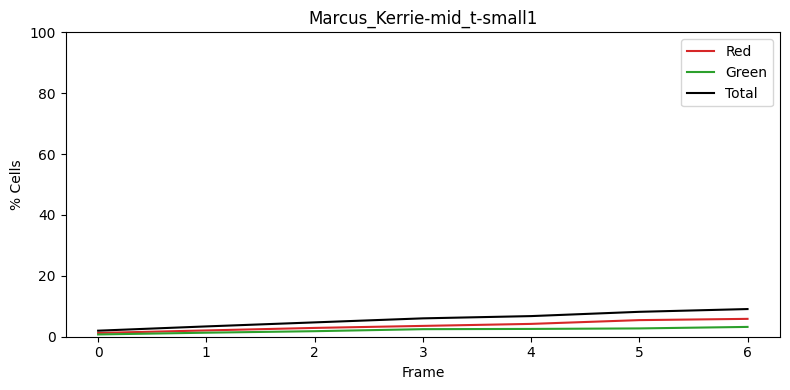

,frame,Red_pct,Green_pct,total_positive_pct
2,2,2.892562,1.818182,4.710744
3,3,3.553719,2.479339,6.033058
4,4,4.214876,2.561983,6.776860
5,5,5.454545,2.727273,8.181818
6,6,5.867769,3.223140,9.090909


In [7]:
# Percentage curves
summary_persistent = compute_persistent_percentages(assignments_df, n_frames, fluorophore_names)
fig, ax = plot_persistent_percentages(summary_persistent, fluorophore_names, title=tiff_path.stem)
plt.show()

summary_persistent.tail()

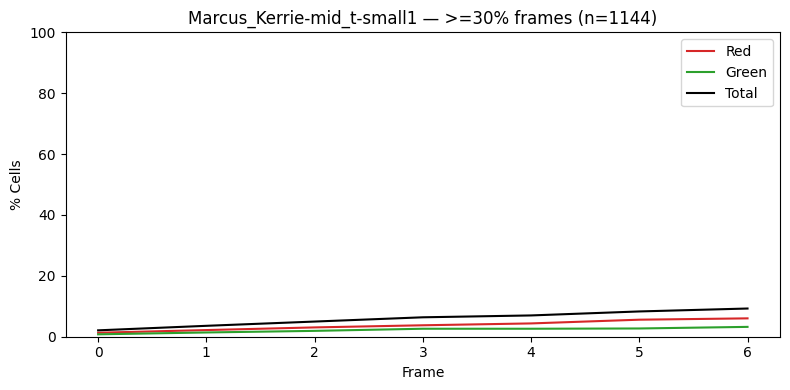

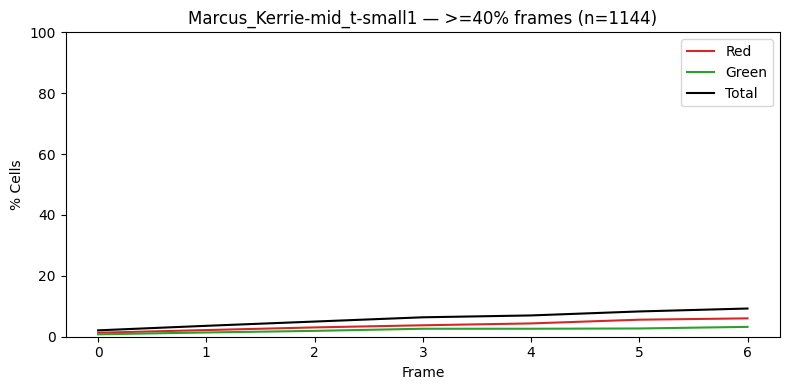

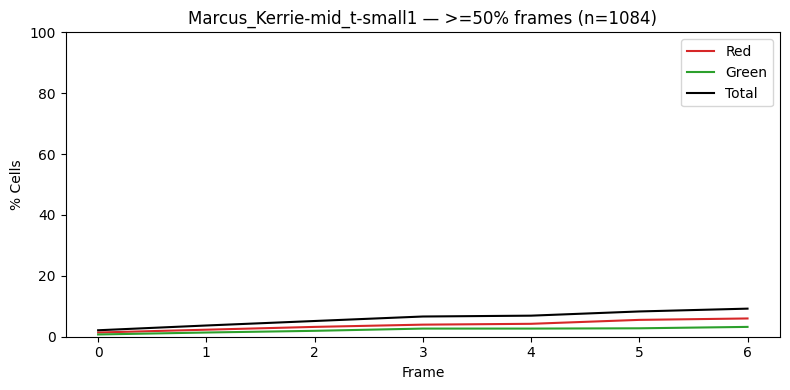

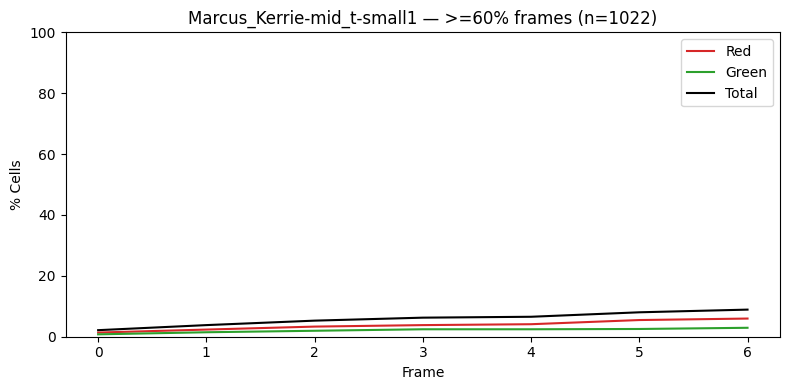

In [8]:
# Filtered by frame presence
for cutoff in cutoff_pcts:
    filt_df = _filter_persistent_by_frame_presence(assignments_df, linked_labels, n_frames, cutoff)
    n_cells = len(filt_df)
    if n_cells == 0:
        print(f"No cells at >= {cutoff}% frame presence, skipping")
        continue
    filt_summary = compute_persistent_percentages(filt_df, n_frames, fluorophore_names)
    fig, _ = plot_persistent_percentages(
        filt_summary, fluorophore_names,
        title=f"{tiff_path.stem} — >={cutoff}% frames (n={n_cells})"
    )
    plt.show()

In [9]:
# Per-frame data
print(f"Per-frame rows: {len(persistent_per_frame)}")
persistent_per_frame.head(10)

Per-frame rows: 7139


,label_id,frame,area,roundness,Red_positive_area,Green_positive_area,fate
0,1,0,3278,0.459280,0.0,0.0,negative
1,1,1,2828,0.636943,0.0,0.0,negative
2,1,2,3245,0.559901,0.0,0.0,negative
3,1,3,2615,0.461666,0.0,0.0,negative
4,1,5,2856,0.659929,0.0,0.0,negative
5,1,6,4350,0.493877,0.0,0.0,negative
6,2,0,3046,0.590695,0.0,0.0,negative
7,2,1,3451,0.873645,0.0,0.0,negative
8,2,2,3192,0.465704,0.0,0.0,negative
9,2,3,4203,0.757392,0.0,0.0,negative


In [12]:
import napari

# Build cumulative persistent labels: at frame t, only show cells whose
# first positive frame for that fate is <= t
cumulative_persistent = {}
for fn in fluorophore_names:
    fate_cells = assignments_df.loc[
        assignments_df["fate"] == fn, ["label_id", f"first_{fn}_frame"]
    ]
    out = np.zeros_like(linked_labels)
    for _, row in fate_cells.iterrows():
        lid = int(row["label_id"])
        first_f = int(row[f"first_{fn}_frame"])
        for frame in range(first_f, n_frames):
            mask = linked_labels[frame] == lid
            out[frame][mask] = lid
    cumulative_persistent[fn] = out

viewer = napari.Viewer()
viewer.add_labels(linked_labels, name="All cells")
for i, fn in enumerate(fluorophore_names):
    viewer.add_image(fluor_images[fn], name=fn, blending="additive")
    viewer.add_labels(
        positive_cell_labels[fn].astype(np.int32),
        name=f"{fn} positive (this frame)",
        opacity=0.4,
    )
    viewer.add_labels(
        cumulative_persistent[fn].astype(np.int32),
        name=f"{fn} persistent (cumulative)",
        opacity=0.5,
    )
napari.run()

---
## 4b. Snapshot analysis

In [ ]:
snapshot_df = assign_snapshot_fates(linked_labels, frame_cell_pos)
snapshot_df = snapshot_df.sort_values(["label_id", "frame"]).reset_index(drop=True)

print(f"Snapshot rows: {len(snapshot_df)}")
print(f"Categories: {sorted(snapshot_df['category'].unique())}")
print(f"\nCategory distribution:\n{snapshot_df['category'].value_counts().to_string()}")
snapshot_df.head(10)

In [ ]:
# Percentage curves
summary_snapshot, cats = compute_snapshot_percentages(snapshot_df, n_frames)
fig, ax = plot_snapshot_percentages(summary_snapshot, cats, title=tiff_path.stem)
plt.show()

summary_snapshot.tail()

In [ ]:
# Filtered by frame presence — percentages, trajectories, and timelines
for cutoff in cutoff_pcts:
    ft, fs = _filter_by_frame_presence(tracks_df, snapshot_df, n_frames, cutoff)
    n_cells = fs["label_id"].nunique() if len(fs) > 0 else 0
    if n_cells == 0:
        print(f"No cells at >= {cutoff}% frame presence, skipping")
        continue

    filt_summary, filt_cats = compute_snapshot_percentages(fs, n_frames)
    fig, _ = plot_snapshot_percentages(
        filt_summary, filt_cats,
        title=f"{tiff_path.stem} — >={cutoff}% frames (n={n_cells})"
    )
    plt.show()

    if len(ft) > 0:
        fig, _ = plot_snapshot_trajectories(
            ft, fs,
            title=f"{tiff_path.stem} — trajectories >={cutoff}% (n={n_cells})"
        )
        plt.show()

        fig, _ = plot_snapshot_cell_timelines(
            fs, tracks_df=ft,
            title=f"{tiff_path.stem} — timelines >={cutoff}% (n={n_cells})"
        )
        plt.show()

---
## 5. Save outputs (optional)

In [ ]:
# Uncomment to save CSVs
# assignments_df.to_csv(work_dir / "assignments_persistent.csv", index=False)
# persistent_per_frame.to_csv(work_dir / "persistent_per_frame.csv", index=False)
# snapshot_df.to_csv(work_dir / "snapshot.csv", index=False)
# summary_persistent.to_csv(work_dir / "percentages_persistent.csv", index=False)
# summary_snapshot.to_csv(work_dir / "percentages_snapshot.csv", index=False)